In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)

print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

0.6777 74.71913613009617 74.71913613009617


In [2]:
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins
r_edges = np.linspace(5, 15, (15-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0 

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [3]:
# bin sim data
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

vpeclos_ls  = []
vphyslos_ls = []
rlos_ls = []
R_ls = []
M_ls = []

with h5.File(vel_path, 'r') as hdf:
    for k, M in enumerate(Mvirs):
        rel_R = hdf[f'R/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_R, r_edges) - 1
        
        for i in range(len(r_cens)):
            mask = bin_indices == i
            vpeclos_ls.append(vpec[mask])
            vphyslos_ls.append(vphys[mask])
            rlos_ls.append(rel_rlos[mask])
            R_ls.append(rel_R[mask])
            M_ls.append(Mvir[mask])

Define model, obtained by integrating over a gaussian:

$$ P(v_{\rm LOS}|R) = \int dr_{\rm LOS} \mathcal{N}(\langle r_{\rm LOS} \rangle = v_{\rm LOS} /aH, \sigma_{r_{\rm LOS}} = \sigma_v / aH)\rho(r)
$$

Fitting for \sigma_v in each bin. First, we can try an example bin with $\sigma_v=\sigma_{v,\rm obs}$. 

In [38]:
# define model
from scipy.integrate import quad

def P_rlos(rlos, vlos, mu, sigma):

    mix = 0.5*( norm.pdf(rlos, loc=vlos/(a*H)-mu, scale=sigma/(a*H)) + norm.pdf(rlos, loc=vlos/(a*H)+mu, scale=sigma/(a*H)))
    #mix = 0.5*( norm.pdf(rlos, loc=-mu, scale=sigma/(a*H)) + norm.pdf(rlos, loc=+mu, scale=sigma/(a*H)))

    return mix #/ np.sum(mix*np.diff(rlos)[0])

def P_vlos(vlos, mu, sigma, R, M):

    n_gal = 0.014 # h^3 Mpc^-3 , avg dens of gals in sim
 
    H = cosmo.Hz(redshift)
    rlos_p = vlos/(a*H)

    prefac = R/(a*H) / np.sqrt(R**2 + rlos_p**2)

    integral = np.array([quad(lambda rlos: P_rlos(rlos, v, mu, sigma)*n_gal * ( 1 + cf_inf(np.sqrt( R**2 + rlos**2 ), M, cf_pars) ), -80, 80)[0] for v in vlos])

    dist = prefac * integral

    return dist / np.sum(dist * np.diff(vlos)[0] )


In [20]:
bin_num = 50

LOS_hists = np.zeros((bin_num, len(Mvirs), len(r_cens)))

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k

        hist, v_edges = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)

        v_cens = (v_edges[:-1] + v_edges[1:]) / 2 

        LOS_hists[:, k, i] = hist  

In [7]:
def P_H(vlos, R, M):

    n_gal = 0.014 # h^3 Mpc^-3 , avgh dens of gals in sim
 
    H = cosmo.Hz(redshift)
    rlos_p = vlos/(a*H)

    numerator = R * n_gal * ( 1 + cf_inf(np.sqrt( R**2 + rlos_p**2 ), M, cf_pars) )

    denominator = a*H*np.sqrt( R**2 + rlos_p**2 )#*Sigma_inf(R, M, cf_pars) # a*H*R*Sigma_inf(R, M, cf_pars)

    dist = numerator/denominator

    return dist / np.sum(dist * np.diff(vlos)[0] )

In [18]:
from scipy.stats import uniform
from scipy.optimize import curve_fit

Text(0.5, 0, '$v_{\\rm LOS}$')

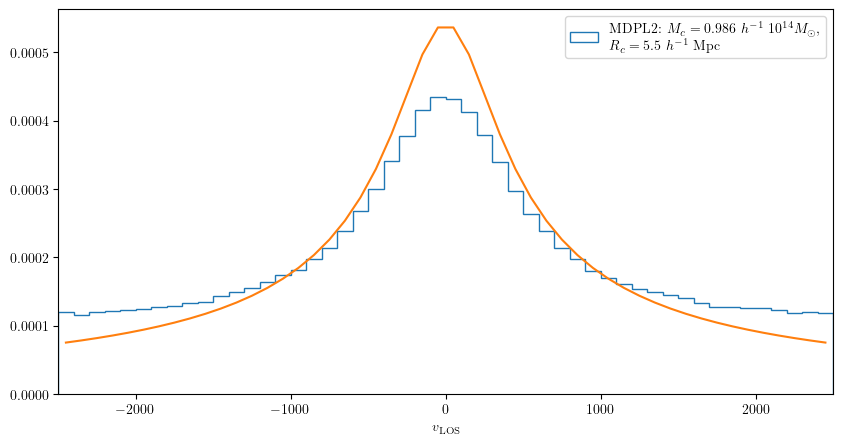

In [54]:
i = 0
k = 0

mvirs = Mvirs/1e14


def P_test(vlos, a, sigma):
    P1 = P_vlos(vlos, sigma, r_cens[i], Mvirs[k])
    P2 = uniform.pdf(vlos)

    mix = a*P1 + (1-a)*P2

    return mix#/np.sum(mix*np.diff(vlos)[0])

vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:] + vedges[:-1])

plt.figure(figsize=(10, 5))

denom = 2
f = 1/denom #1/4

hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step', label=f"MDPL2: $M_c={mvirs[k]:.3} \ h^{{-1}}\ 10^{{14}} M_\odot$, \n $R_c={r_cens[i]} \ h^{{-1}}$ Mpc")

#plt.plot(vcens, P_H(vcens, r_cens[i], Mvirs[k]) ,label='$P_H$')

#sigs = [250, 500, 1000, 2000, 10_000, 100_000]

#for sig in sigs:
#dist = P_vlos(vcens, 500, r_cens[i], Mvirs[k])
#plt.plot(vcens, (1/2.1)*(dist)+(1-1/2.1)*0.00018, label=f'integ. over Gaussian w/ $\sigma_v={500}$ km/s')

#p, c = curve_fit(P_test, vcens, hist, p0=[0.5, 500])
plt.plot(vcens, P_vlos(vcens, 200, 400, r_cens[i], Mvirs[k]))

plt.legend(loc='upper right', fontsize=10)
plt.margins(x=0)
#plt.title(f'Example comparison of "Hubble" component: $f=1/{denom}$')
plt.xlabel(r"$v_{\rm LOS}$")

In [12]:
1/2.1

0.47619047619047616

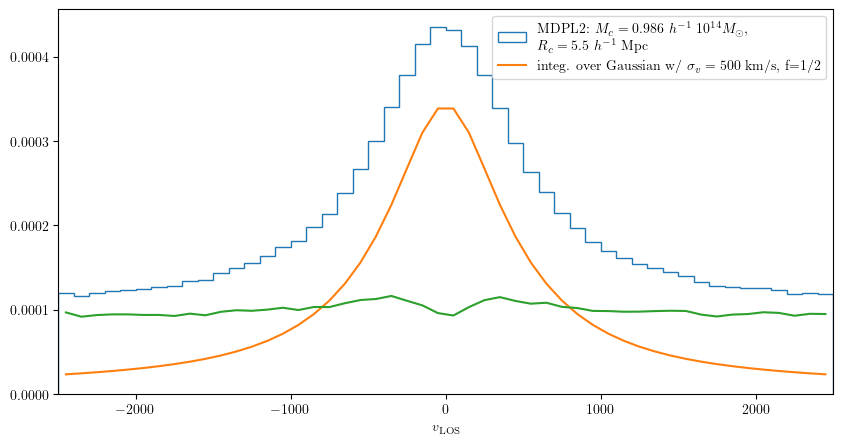

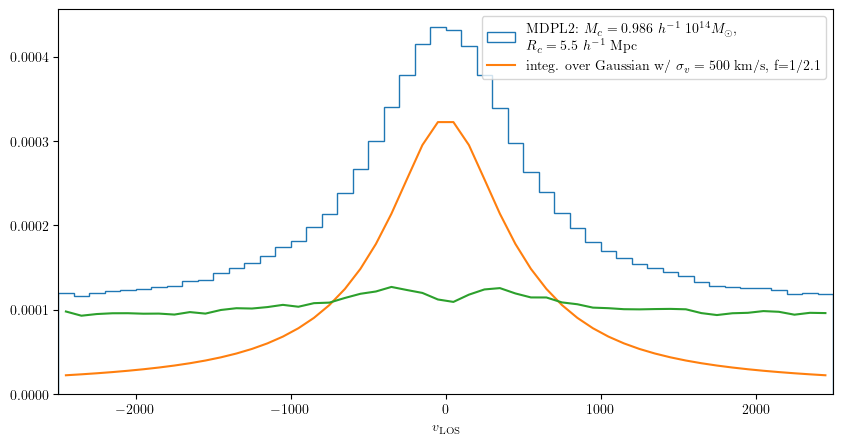

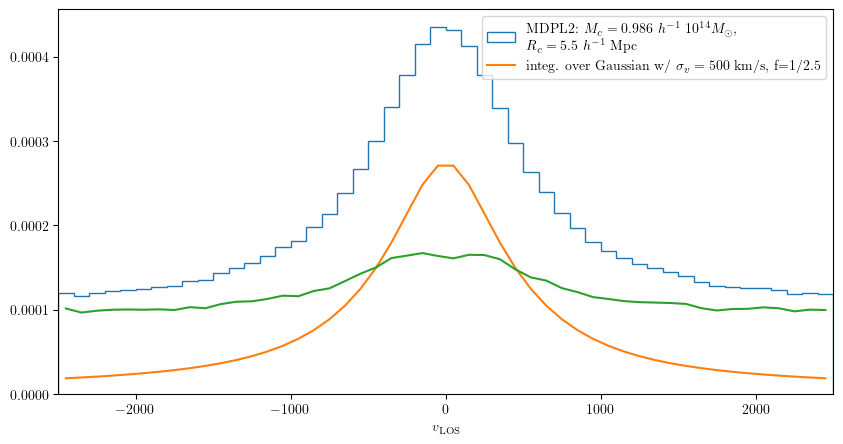

In [9]:
i = 0
k = 0

mvirs = Mvirs/1e14

vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:] + vedges[:-1])


#denom = 2.05
denoms = [2, 2.1, 2.5]
for denom in denoms:
    plt.figure(figsize=(10, 5))

    f = 1/denom #1/4

    hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step', label=f"MDPL2: $M_c={mvirs[k]:.3} \ h^{{-1}}\ 10^{{14}} M_\odot$, \n $R_c={r_cens[i]} \ h^{{-1}}$ Mpc")
    dist = P_vlos(vcens, 500, r_cens[i], Mvirs[k])

    plt.plot(vcens, f*dist, label=f'integ. over Gaussian w/ $\sigma_v={500}$ km/s, f=1/{denom}')
    plt.plot(vcens, hist - f*dist)

    plt.legend(loc='upper right', fontsize=10)
    plt.margins(x=0)
    #plt.title(f'Example comparison of "Hubble" component: $f=1/{denom}$')
    plt.xlabel(r"$v_{\rm LOS}$")

In [7]:
import numdifftools as nd

In [8]:
p_init = [0.5, 500, 2]

mm_pars_init = np.zeros((len(Mvirs), len(r_cens), len(p_init)))

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        soln = scipy.optimize.minimize(lambda p: -llh_ind(p, v_cens, LOS_hists[:, k, i]), p_init, 
                                            bounds = [(0, 1), (0, 1500), (0, 10)], 
                                            method='nelder-mead', 
                                            )
        mm_pars_init[k, i] = soln.x

mm_pars = np.zeros((len(Mvirs), len(r_cens), len(p_init)))
mm_errs = np.zeros((len(Mvirs), len(r_cens), len(p_init)))

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        soln = scipy.optimize.minimize(lambda p: -llh_ind(p, v_cens, LOS_hists[:, k, i]), mm_pars_init[k, i], 
                                            bounds = [(0, 1), (0, 1500), (0, 10)], 
                                            method='L-BFGS-B' , 
                                            )
        mm_pars[k, i] = soln.x

        def neg_llh(p):
            return -llh_ind(p, v_cens, LOS_hists[:, k, i])
        
        # Compute Hessian at the best-fit point
        hess_func = nd.Hessian(neg_llh)
        hessian = hess_func(soln.x)

        cov_matrix = np.linalg.inv(hessian)

        uncertainties = np.sqrt(np.diag(cov_matrix))

        mm_errs[k, i] = uncertainties #np.sqrt(soln.hess_inv(soln.x))

In [9]:
mvirs = Mvirs / 1e14

<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_616745/122794710.py:10: SyntaxWarning: invalid escape sequence '\ '
  ax[0].set_ylabel(f'$M_c = {mvirs[k]:.3}\ 10^{{14}}\ h^{{-1}} M_\odot$', fontsize=25)
/tmp/ipykernel_616745/122794710.py:10: SyntaxWarning: invalid escape sequence '\ '
  ax[0].set_ylabel(f'$M_c = {mvirs[k]:.3}\ 10^{{14}}\ h^{{-1}} M_\odot$', fontsize=25)
/tmp/ipykernel_616745/122794710.py:10: SyntaxWarning: invalid escape sequence '\o'
  ax[0].set_ylabel(f'$M_c = {mvirs[k]:.3}\ 10^{{14}}\ h^{{-1}} M_\odot$', fontsize=25)
/tmp/ipykernel_616745/122794710.py:12: SyntaxWarning: invalid escape sequence '\ '

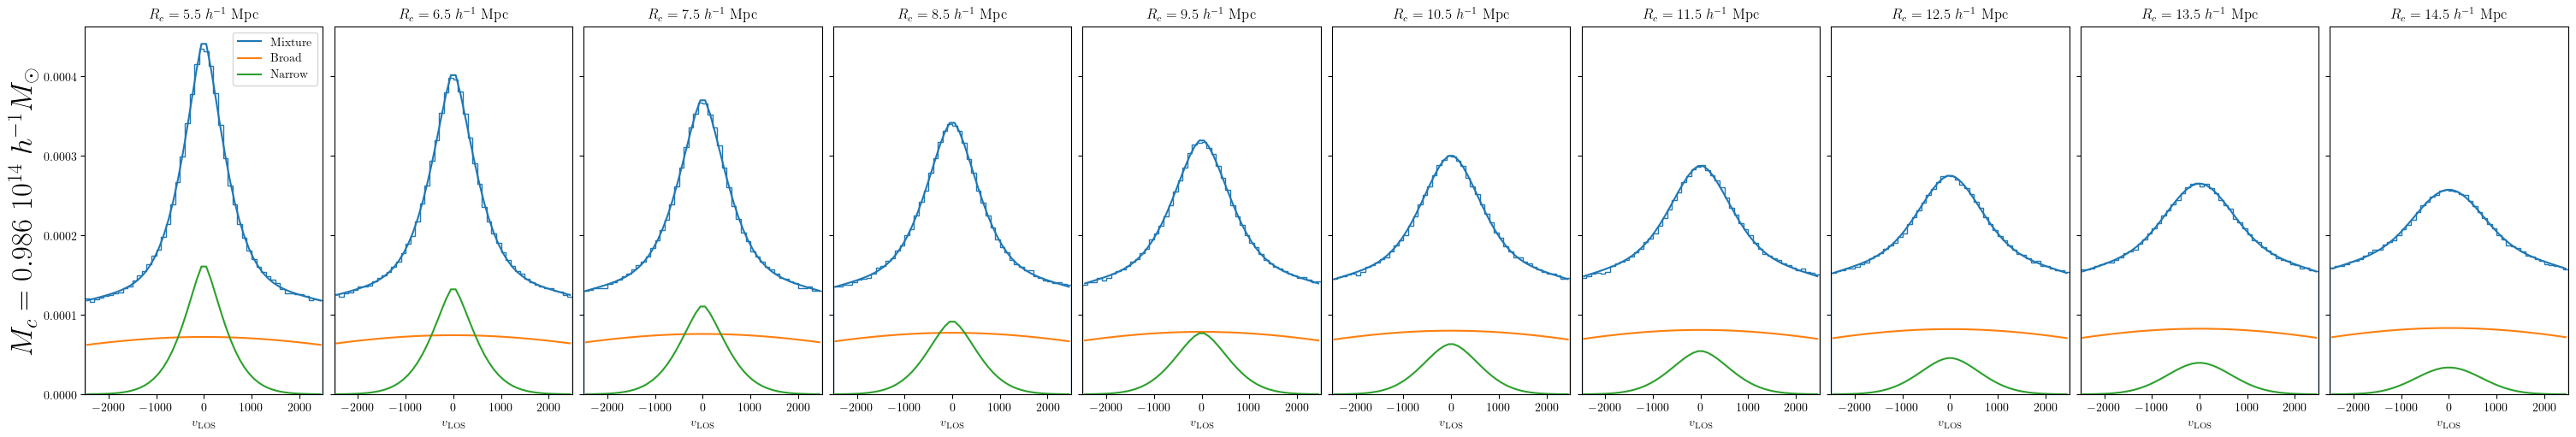

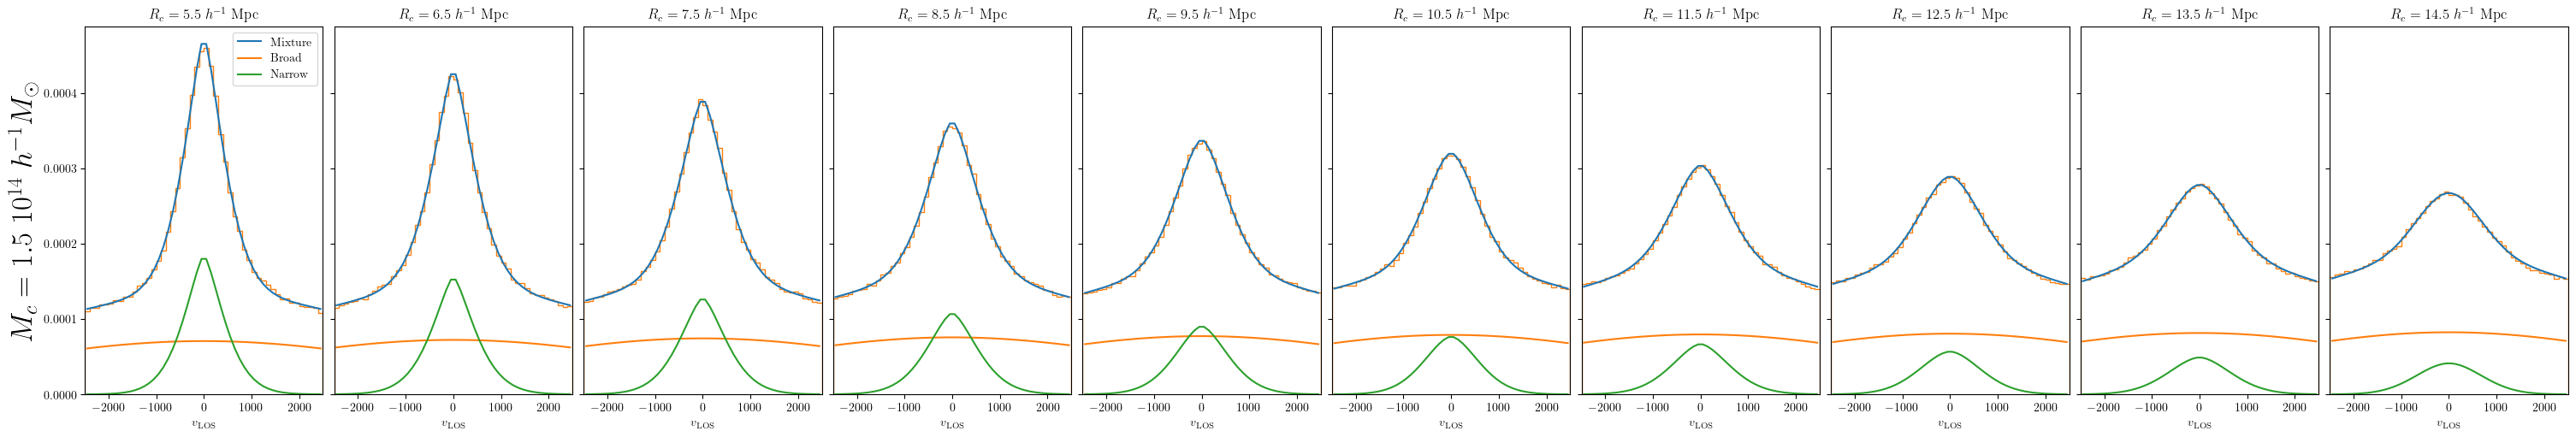

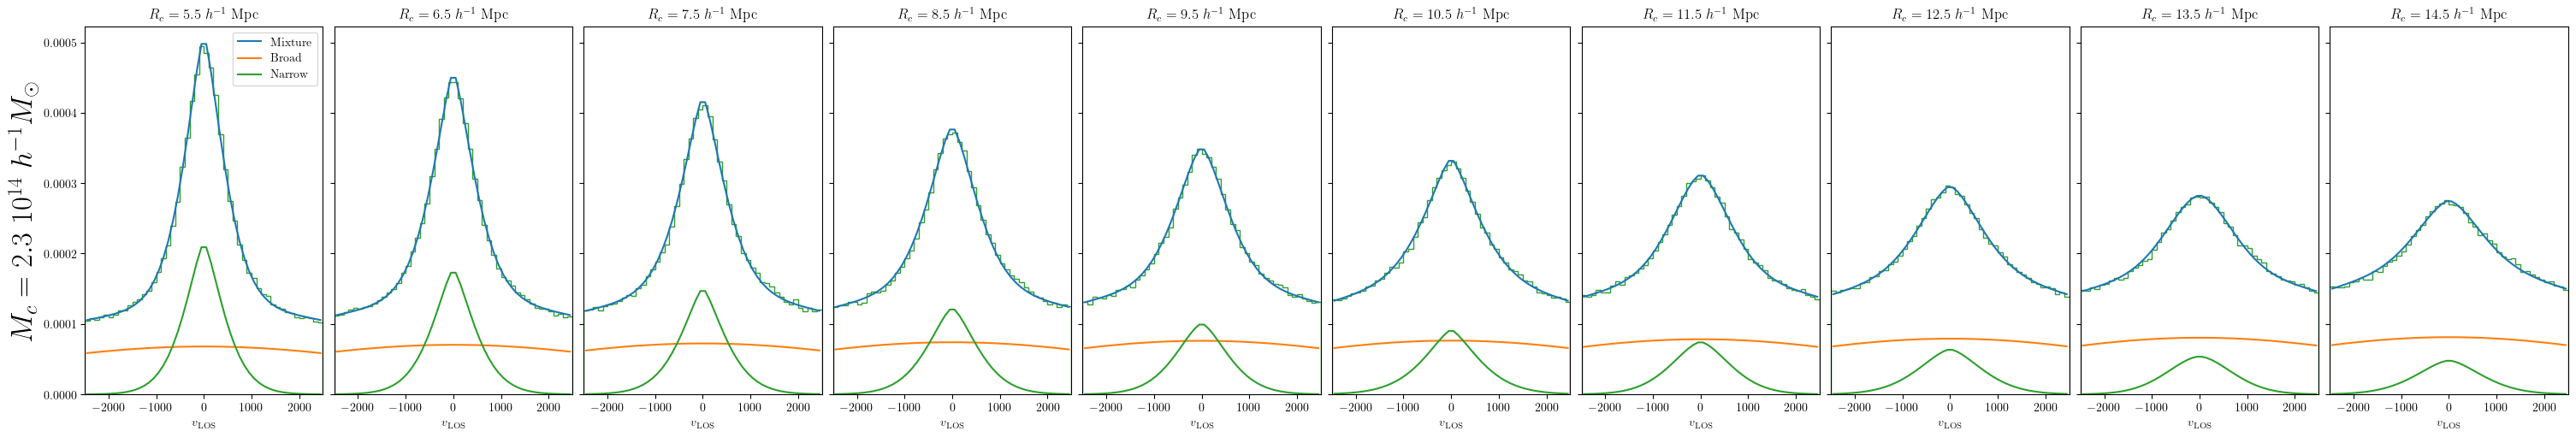

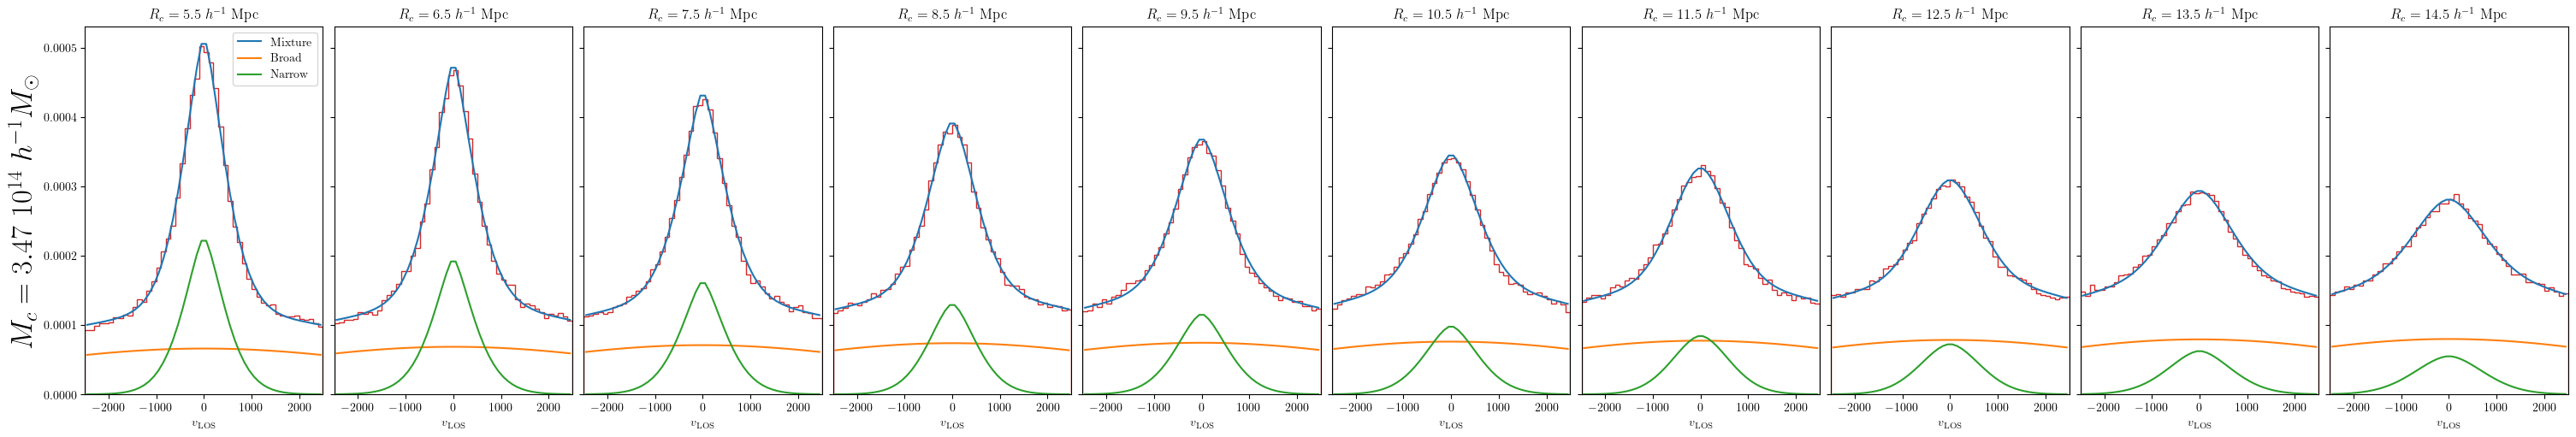

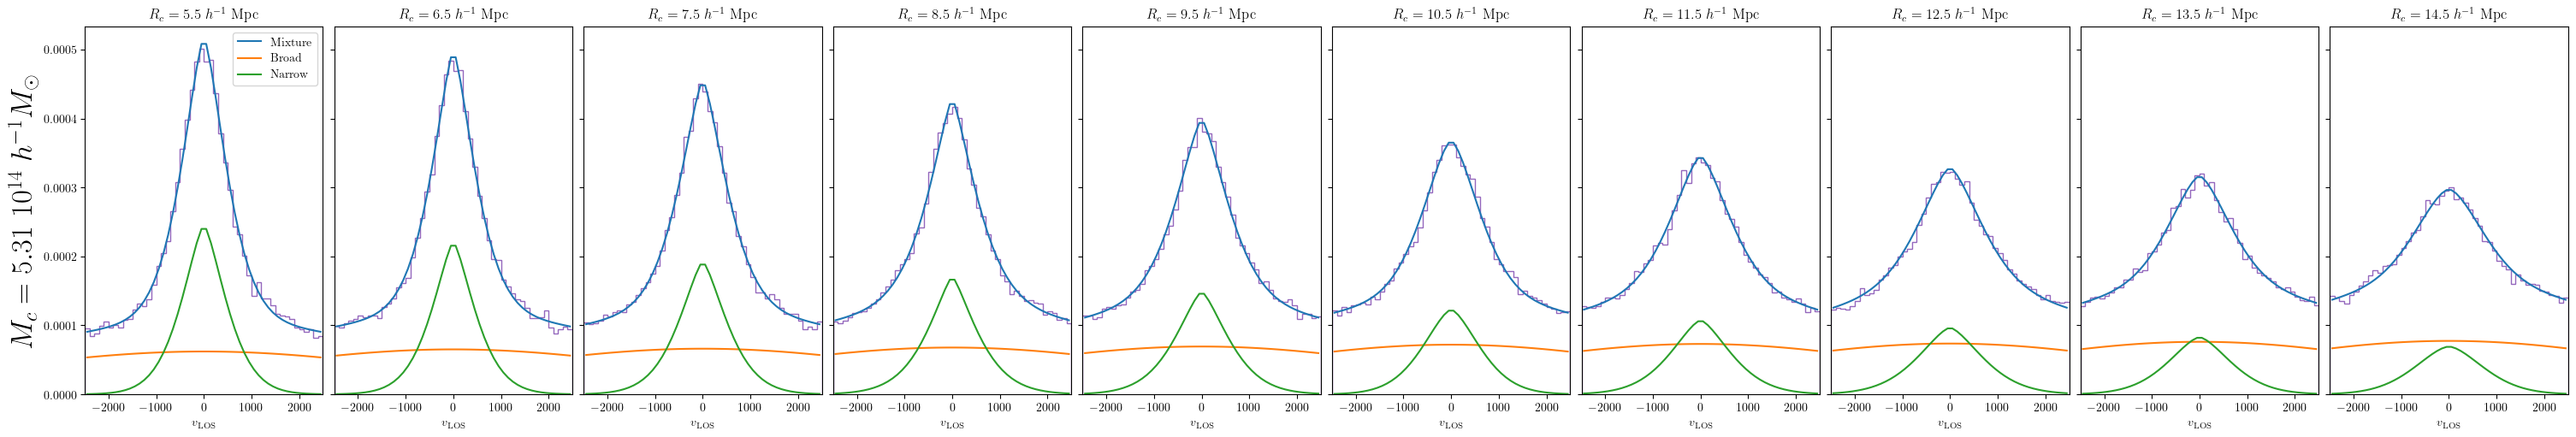

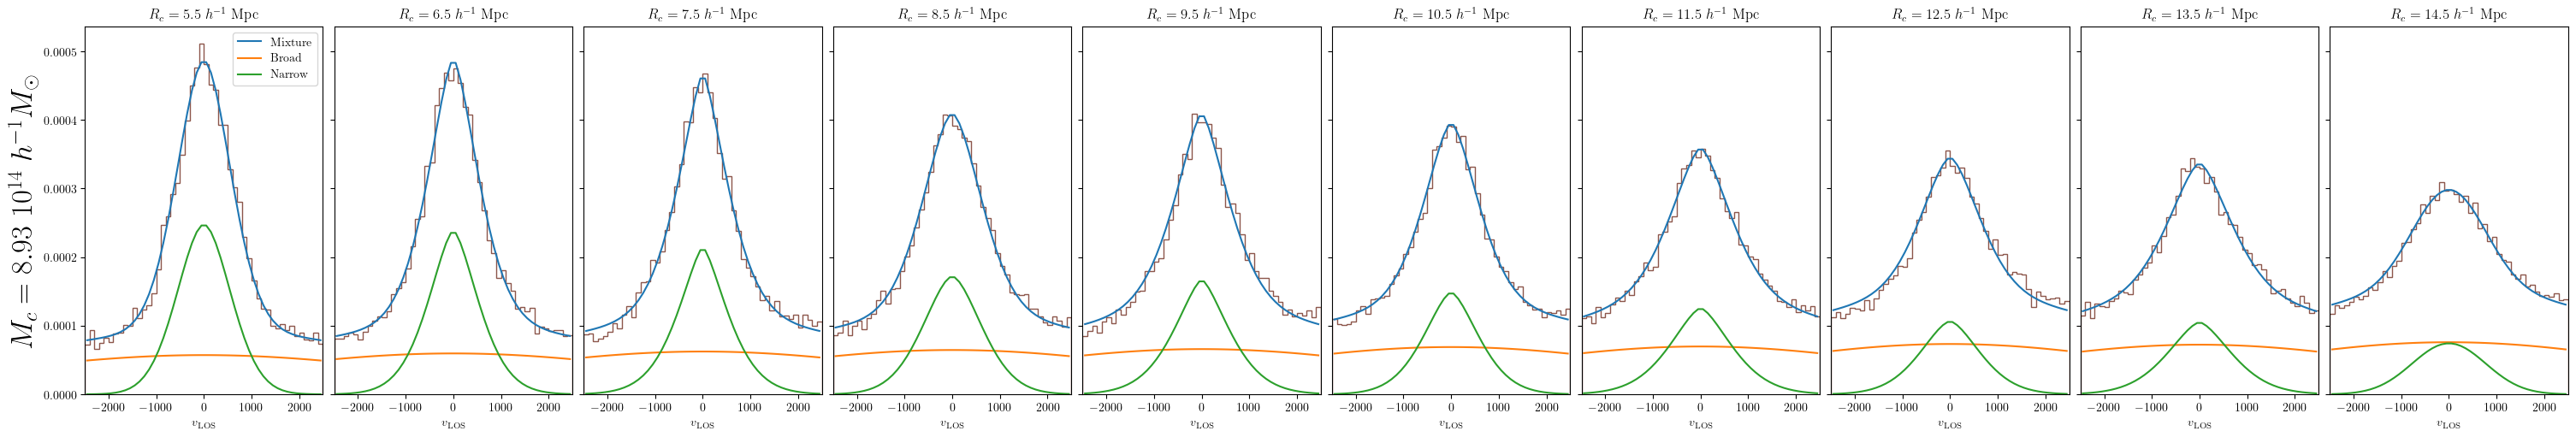

In [19]:

for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, len(r_cens), figsize=(30, 5), sharey='row', sharex=True, layout='constrained')

    for i in range(len(r_cens)):
        hist, _, _ = ax[i].hist(vphyslos_ls[i + k*len(r_cens)], bins=v_edges, range=[-2500, 2500], density=True, histtype='step', color=f'C{k}')
        ax[i].plot(v_cens, P_mm(v_cens, mm_pars[k, i]), label='Mixture')
        ax[i].plot(v_cens, mm_pars[k, i, 0]*P_broad(v_cens,), label='Broad')
        ax[i].plot(v_cens, (1-mm_pars[k, i, 0])*P_D(v_cens, mm_pars[k, i, 1], mm_pars[k, i, 2]), label='Narrow') 
        ax[i].set_xlabel(r"$v_{\rm LOS}$")
        ax[0].set_ylabel(f'$M_c = {mvirs[k]:.3}\ 10^{{14}}\ h^{{-1}} M_\odot$', fontsize=25)       
        ax[i].margins(x=0)
        ax[i].set_title(f'$R_c = {r_cens[i]}\ h^{{-1}}$ Mpc')

    ax[0].legend(loc='upper right')


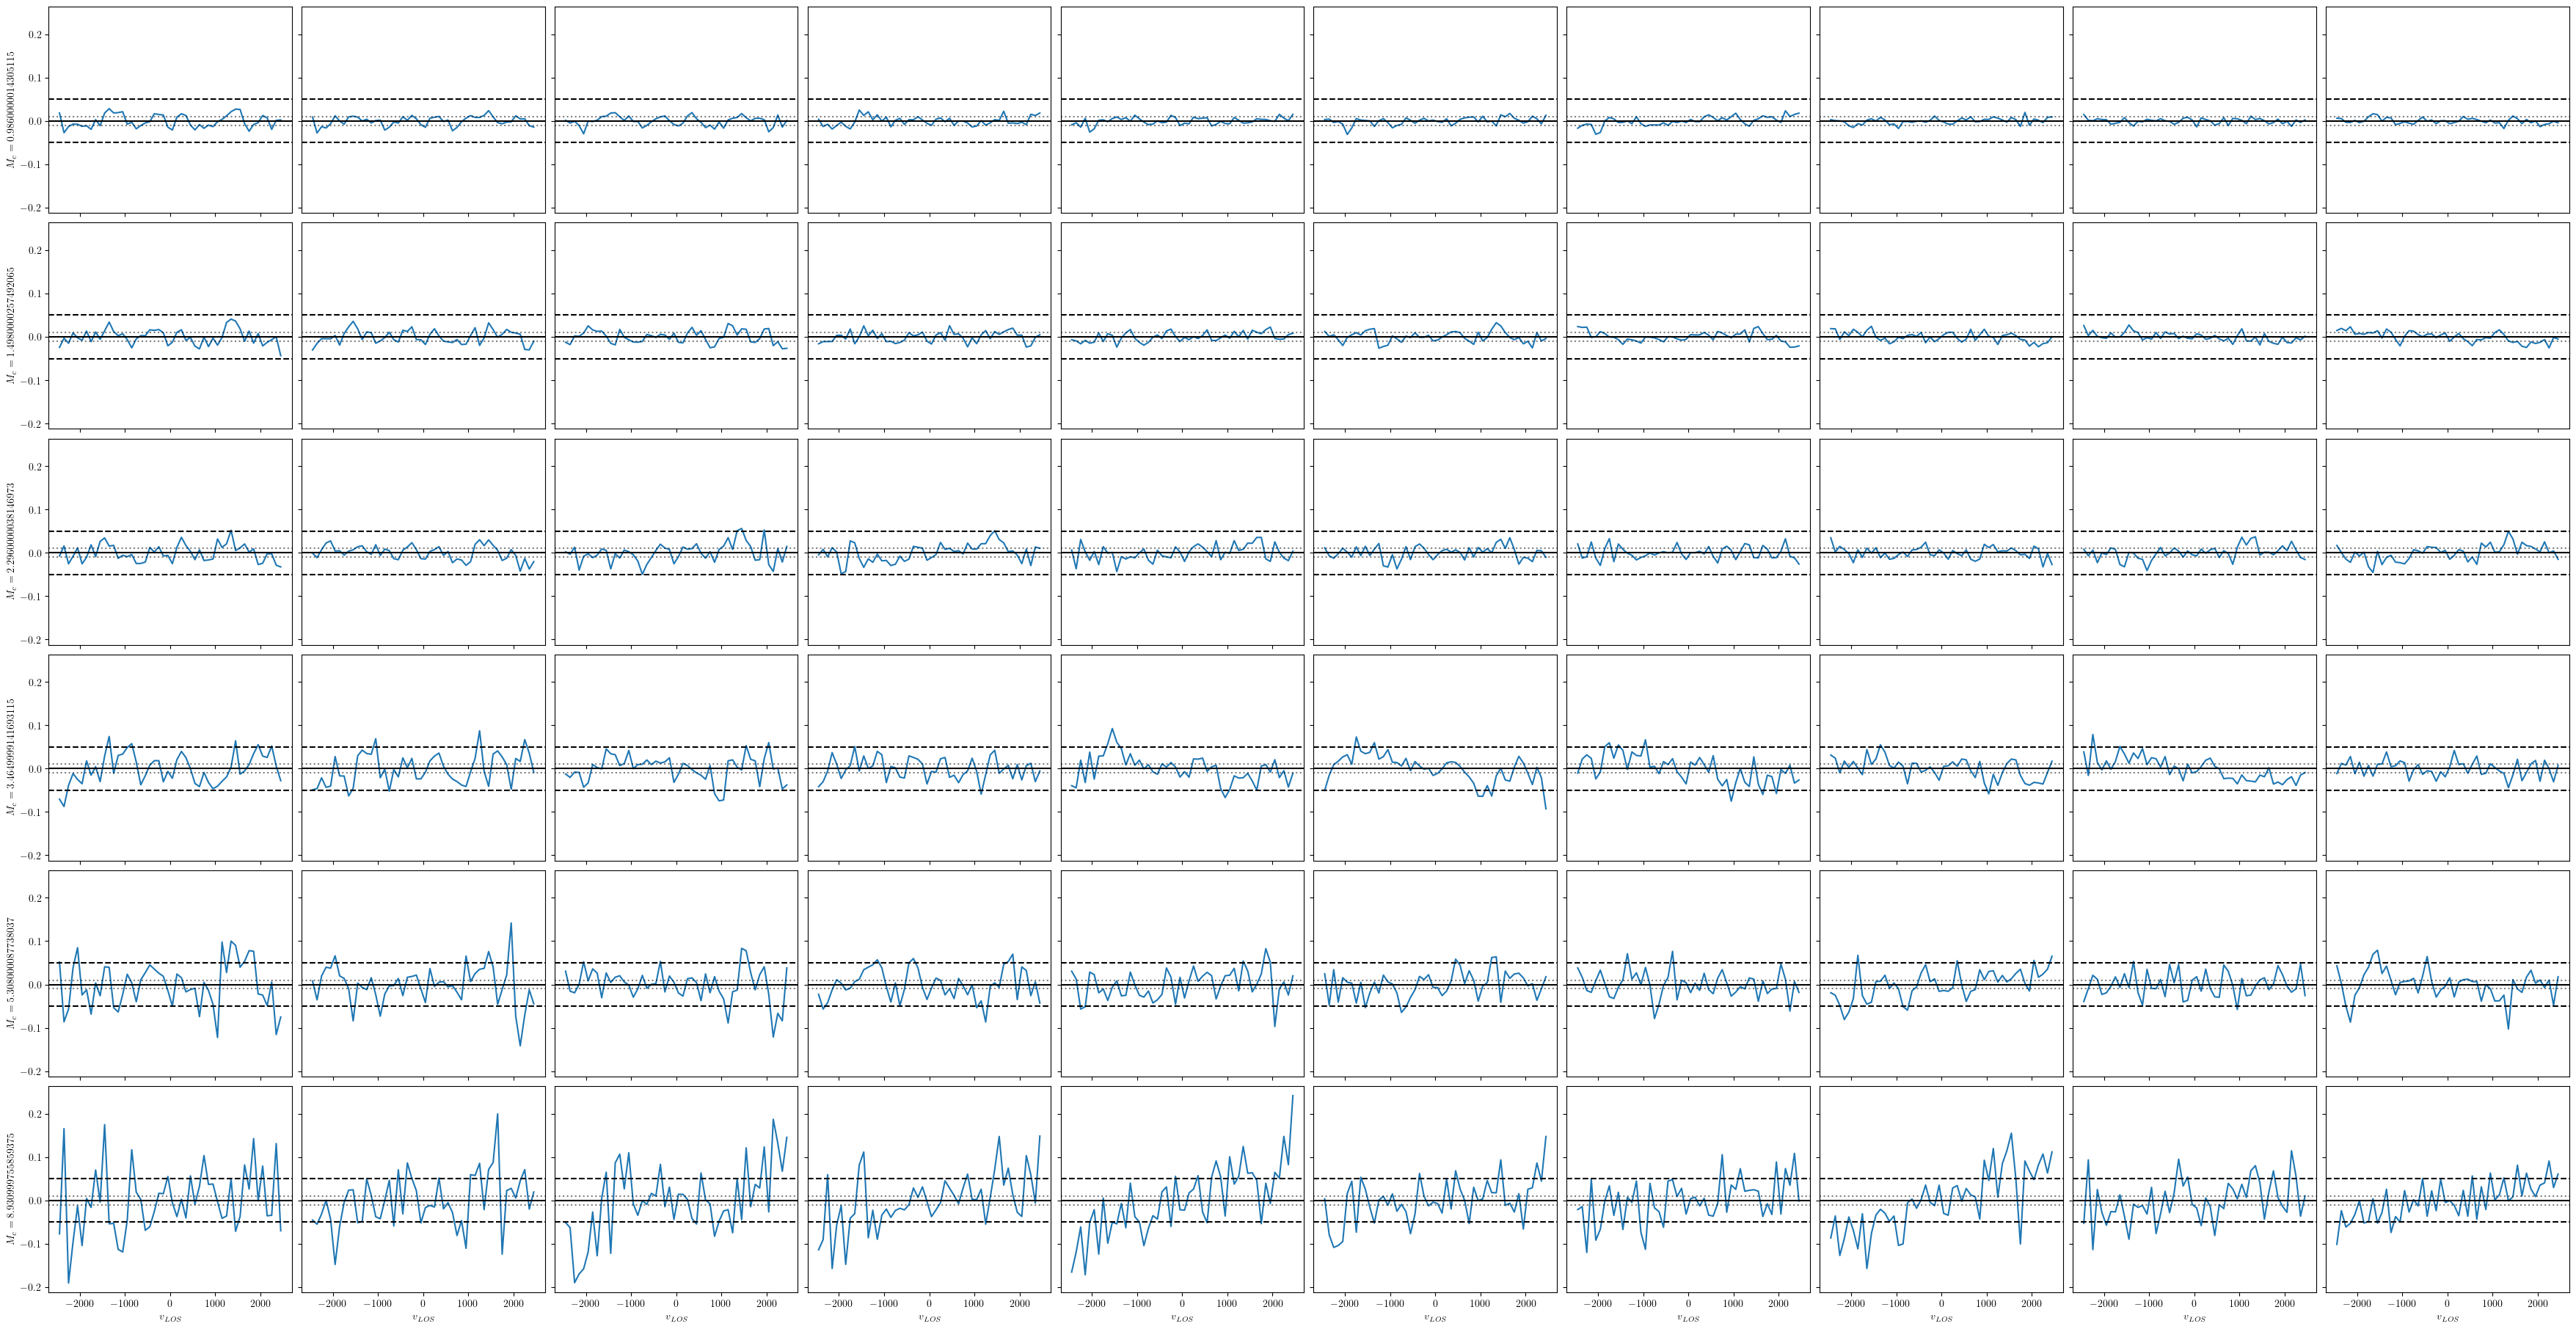

In [26]:
# differences

fig, ax = plt.subplots(len(Mvirs), len(r_cens), figsize=(35, 3*len(Mvirs)), sharey=True, sharex=True, layout='constrained')

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        hist, _ = np.histogram(vphyslos_ls[i + k*len(r_cens)], bins=v_edges, range=[-2500, 2500], density=True, )
        ax[k, i].plot(v_cens, (hist - P_mm(v_cens, mm_pars[k, i]))/P_mm(v_cens, mm_pars[k, i]))
        ax[k, i].axhline(0, c='k', ls='-')
        ax[k, i].axhline(-0.05, c='k', ls='--')
        ax[k, i].axhline(0.05, c='k', ls='--')
        ax[k, i].axhline(-0.01, c='k', ls=':', alpha=0.5)
        ax[k, i].axhline(0.01, c='k', ls=':', alpha=0.5)
        ax[-1, i].set_xlabel(r"$v_{LOS}$")
        ax[k, 0].set_ylabel(f"$M_c = {mvirs[k]}$")       



In [8]:
from scipy.optimize import curve_fit

In [84]:
import george
from george import kernels
from scipy.optimize import minimize

def fit_gp_2d_george(r_cens, mvirs, data, data_err):
    """
    Fit 2D GP using george for each curve set.
    
    Parameters:
    -----------
    r_cens : array of shape (len(R),)
        R bin centers
    mvirs : array of shape (len(M),)
        M bin centers (virial masses)
    data : array of shape (len(M), len(R), 3)
    
    Returns:
    --------
    gp_models : list of george GP objects
    """
    n_M, n_R, n_curves = data.shape
    gp_models = []
    
    # Create 2D input grid
    M_grid, R_grid = np.meshgrid(mvirs, r_cens, indexing='ij')
    X = np.column_stack([M_grid.ravel(), R_grid.ravel()])
    
    # Optionally scale input features too (especially useful if Mvirs >> r_cens)
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_scaled = (X - X_mean) / X_std

    for curve_idx in range(n_curves):
        # Flatten the data for this curve
        y = data[:, :, curve_idx].ravel()

        # Store original scale statistics
        y_mean = y.mean()
        y_std = y.std()
        
        # Standardize y to have mean 0 and std 1
        y_scaled = (y - y_mean) / y_std
        
        # Estimate uncertainties (or use your actual measurement errors)
        yerr = data_err[:, :, curve_idx].ravel() #np.ones_like(y) * 0.1  # Replace with actual errors if available
        yerr_scaled = yerr / y_std

        # Define kernel with separate length scales for each dimension
        # ExpSquaredKernel is the RBF/squared exponential kernel
        # The metric parameter allows different length scales per dimension
        kernel =  kernels.ExpSquaredKernel(metric=[1.0, 1.0], ndim=2)
        
        # Create GP object
        # The yerr parameter adds white noise (diagonal covariance)
        gp = george.GP(kernel)
        gp.compute(X_scaled, yerr_scaled)
        
        # Define negative log-likelihood for optimization
        def neg_ln_like(p):
            gp.set_parameter_vector(p)
            return -gp.log_likelihood(y_scaled)
        
        def grad_neg_ln_like(p):
            gp.set_parameter_vector(p)
            return -gp.grad_log_likelihood(y_scaled)
        
        # Optimize hyperparameters
        initial_params = gp.get_parameter_vector()
        bounds = [(np.log(1e-5), np.log(1e5))] * len(initial_params)
        
        result = minimize(neg_ln_like, initial_params, jac=grad_neg_ln_like,
                         bounds=bounds, method='L-BFGS-B')
        
        gp.set_parameter_vector(result.x)
        
        gp_models.append(gp)
        
        print(f"Curve {curve_idx} optimized parameters:")
        print(f"  Kernel parameters: {gp.get_parameter_vector()}")
        print(f"  Log-likelihood: {gp.log_likelihood(y_scaled)}")
    
    return gp_models, X_scaled, y_scaled

# Example usage
# r_cens = np.linspace(0, 10, 20)
# mvirs = np.array([1e12, 2e12, 3e12, 4e12, 5e12])
# data = np.random.randn(len(mvirs), len(r_cens), 3)

gp_models, X_train, y_train = fit_gp_2d_george(r_cens, mvirs, mm_pars, mm_errs)

# Make predictions on a finer grid
r_pred = np.linspace(r_cens.min(), r_cens.max(), 100)
M_pred = np.linspace(mvirs.min(), mvirs.max(), 50)
M_grid_pred, R_grid_pred = np.meshgrid(M_pred, r_pred, indexing='ij')
X_pred = np.column_stack([M_grid_pred.ravel(), R_grid_pred.ravel()])

# Predict for first curve
curve_idx = 0
# For faster predictions without full covariance:
mean_pred, var_pred = gp_models[curve_idx].predict(y_train, X_pred, return_var=True)
std_pred = np.sqrt(var_pred)

# For full covariance matrix (slower):
# mean_pred, cov_pred = gp_models[curve_idx].predict(y_train, X_pred, return_cov=True)
# std_pred = np.sqrt(np.diag(cov_pred))

# Reshape for plotting
mean_pred_2d = mean_pred.reshape(len(M_pred), len(r_pred))
std_pred_2d = std_pred.reshape(len(M_pred), len(r_pred))


Curve 0 optimized parameters:
  Kernel parameters: [-0.15878869  1.64515319]
  Log-likelihood: 37.66177461291358
Curve 1 optimized parameters:
  Kernel parameters: [1.35233455 0.34758342]
  Log-likelihood: -0.1572222653878086
Curve 2 optimized parameters:
  Kernel parameters: [-7.62305921  1.0710725 ]
  Log-likelihood: -51.83584306499576


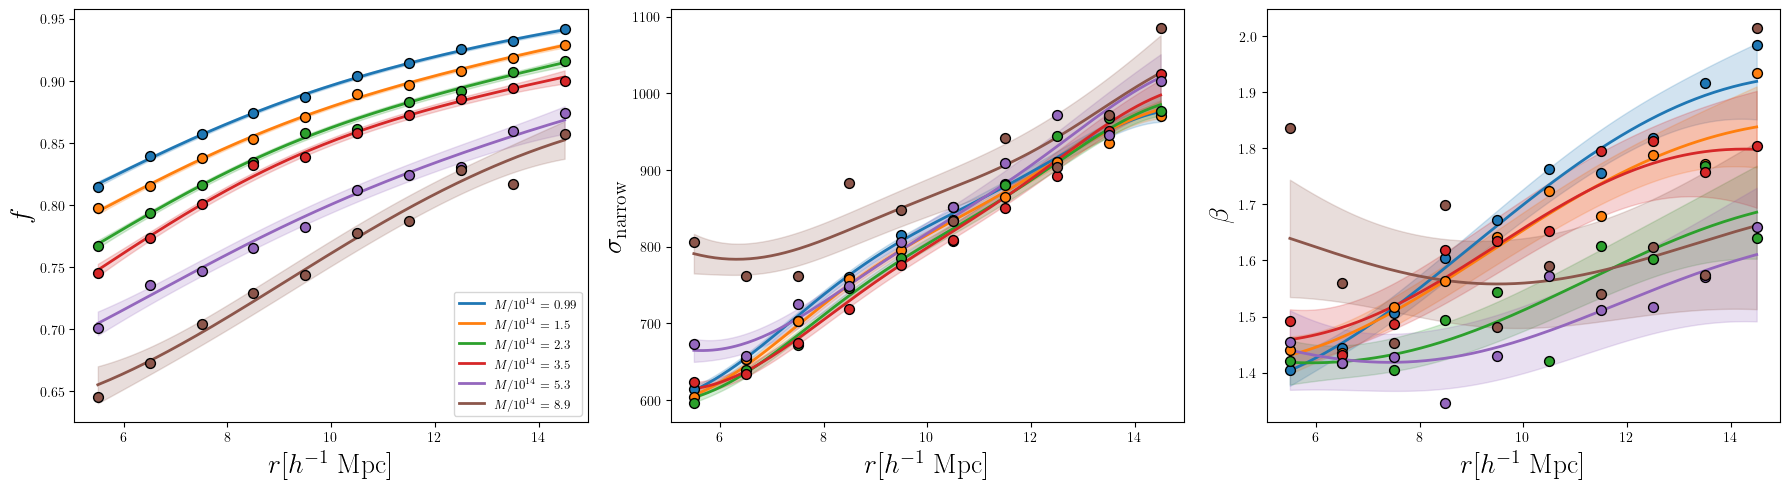

In [99]:
def fit_gp_2d_george_scaled(r_cens, Mvirs, data, data_errs):
    """
    Fit 2D GP using george with proper scaling for each curve set.
    
    Parameters:
    -----------
    r_cens : array of shape (len(R),)
        R bin centers
    Mvirs : array of shape (len(M),)
        M bin centers (virial masses)
    data : array of shape (len(M), len(R), 3)
        Data with different scales for each of 3 curves
    
    Returns:
    --------
    gp_models : list of dicts containing GP objects and scaling info
    """
    n_M, n_R, n_curves = data.shape
    gp_models = []
    
    # Create 2D input grid
    M_grid, R_grid = np.meshgrid(Mvirs, r_cens, indexing='ij')
    X = np.column_stack([M_grid.ravel(), R_grid.ravel()])
    
    # Optionally scale input features too (especially useful if Mvirs >> r_cens)
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_scaled = (X - X_mean) / X_std
    
    for curve_idx in range(n_curves):
        # Flatten the data for this curve
        y = data[:, :, curve_idx].ravel()
        
        # Store original scale statistics
        y_mean = y.mean()
        y_std = y.std()
        
        # Standardize y to have mean 0 and std 1
        y_scaled = (y - y_mean) / y_std
        
        # Estimate uncertainties (scaled to match y_scaled)
        # If you have actual measurement errors, scale them too: yerr_scaled = yerr / y_std
        yerr = data_errs[:, :, curve_idx].ravel() #np.ones_like(y_scaled) * 0.1
        yerr_scaled = yerr / y_std

        # Define kernel on scaled data
        # Start with reasonable initial length scales (order 1 for scaled data)
        kernel = kernels.ExpSquaredKernel(metric=[1.0, 1.0], ndim=2)
        
        # Create GP object
        gp = george.GP(kernel)
        gp.compute(X_scaled, yerr_scaled)
        
        # Define negative log-likelihood for optimization
        def neg_ln_like(p):
            gp.set_parameter_vector(p)
            return -gp.log_likelihood(y_scaled)
        
        def grad_neg_ln_like(p):
            gp.set_parameter_vector(p)
            return -gp.grad_log_likelihood(y_scaled)
        
        # Optimize hyperparameters
        initial_params = gp.get_parameter_vector()
        bounds = [(np.log(1e-3), np.log(1e3))] * len(initial_params)
        
        result = minimize(neg_ln_like, initial_params, jac=grad_neg_ln_like,
                         bounds=bounds, method='L-BFGS-B')
        
        gp.set_parameter_vector(result.x)
        
        # Store GP along with scaling information
        gp_models.append({
            'gp': gp,
            'y_mean': y_mean,
            'y_std': y_std,
            'X_mean': X_mean,
            'X_std': X_std,
            'y_scaled': y_scaled  # Store for predictions
        })
        
        print(f"Curve {curve_idx} (range: {y.min():.2f} - {y.max():.2f}):")
        print(f"  Original: mean={y_mean:.2f}, std={y_std:.2f}")
        print(f"  Kernel parameters: {gp.get_parameter_vector()}")
        print(f"  Log-likelihood: {gp.log_likelihood(y_scaled):.2f}\n")
    
    return gp_models, X


def predict_gp_scaled(gp_model_dict, X_pred):
    """
    Make predictions with a scaled GP model and transform back to original scale.
    
    Parameters:
    -----------
    gp_model_dict : dict
        Dictionary containing GP and scaling info
    X_pred : array of shape (n_pred, 2)
        Prediction points in original scale
    
    Returns:
    --------
    mean_pred : array
        Predictions in original scale
    std_pred : array
        Uncertainties in original scale
    """
    # Scale the prediction points
    X_pred_scaled = (X_pred - gp_model_dict['X_mean']) / gp_model_dict['X_std']
    
    # Predict on scaled data
    mean_scaled, var_scaled = gp_model_dict['gp'].predict(
        gp_model_dict['y_scaled'], 
        X_pred_scaled, 
        return_var=True
    )
    std_scaled = np.sqrt(var_scaled)
    
    # Transform back to original scale
    mean_pred = mean_scaled * gp_model_dict['y_std'] + gp_model_dict['y_mean']
    std_pred = std_scaled * gp_model_dict['y_std']
    
    return mean_pred, std_pred

# Example usage
# r_cens = np.linspace(0.1, 5.0, 20)
# Mvirs = np.logspace(12, 14, 5)  # e.g., 1e12 to 1e14
# data = np.random.randn(len(Mvirs), len(r_cens), 3)
# # Simulate different scales
# data[:, :, 0] = 0.6 + 0.4 * (data[:, :, 0] - data[:, :, 0].min()) / (data[:, :, 0].max() - data[:, :, 0].min())
# data[:, :, 1] = 550 + 550 * (data[:, :, 1] - data[:, :, 1].min()) / (data[:, :, 1].max() - data[:, :, 1].min())
# data[:, :, 2] = 1.3 + 0.7 * (data[:, :, 2] - data[:, :, 2].min()) / (data[:, :, 2].max() - data[:, :, 2].min())

# gp_models, X_train = fit_gp_2d_george_scaled(r_cens, Mvirs, mm_pars, mm_errs)

# # Make predictions using the scaling-aware function
# r_pred = np.linspace(r_cens.min(), r_cens.max(), 100)
# Mvir_specific = Mvirs[2]  # Pick a specific Mvir
# X_test = np.column_stack([np.full_like(r_pred, Mvir_specific), r_pred])

# # Predict for each curve
# for curve_idx in range(3):
#     mean_pred, std_pred = predict_gp_scaled(gp_models[curve_idx], X_test)
    
#     plt.figure(figsize=(10, 6))
#     plt.plot(r_pred, mean_pred, 'b-', linewidth=2, label='GP mean')
#     plt.fill_between(r_pred,
#                      mean_pred - 2*std_pred,
#                      mean_pred + 2*std_pred,
#                      alpha=0.3, label='95% confidence')
    
#     # Plot training data at this Mvir
#     m_idx = np.where(Mvirs == Mvir_specific)[0][0]
#     plt.scatter(r_cens, mm_pars[m_idx, :, curve_idx], 
#                color='red', s=60, zorder=5, label='Data')
    
#     plt.xlabel(r'$r [h^{-1}\ $Mpc]')
#     plt.ylabel('Value')
#     plt.title(f'Curve {curve_idx + 1} at Mvir = {Mvir_specific:.2e}')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()


def plot_gp_predictions_by_M_scaled(gp_models, r_cens, Mvirs, data, r_pred_dense=None):
    """
    Plot GP predictions with proper scaling for each curve.
    """
    n_curves = len(gp_models)
    n_M = len(Mvirs)
    
    if r_pred_dense is None:
        r_pred_dense = np.linspace(r_cens.min(), r_cens.max(), 200)
    
    fig, axes = plt.subplots(1, n_curves, figsize=(6*n_curves, 5))
    
    if n_curves == 1:
        axes = [axes]
    
    #colors = plt.cm.viridis(np.linspace(0, 1, n_M))

    labels = [r"$f$", r"$\sigma_{\rm narrow}$", r"$\beta$"]
    
    for curve_idx in range(n_curves):
        ax = axes[curve_idx]
        
        for m_idx, Mvir in enumerate(Mvirs):
            # Create prediction points at this Mvir
            X_pred = np.column_stack([np.full_like(r_pred_dense, Mvir), r_pred_dense])
            
            # Use the scaling-aware prediction function
            mean_pred, std_pred = predict_gp_scaled(gp_models[curve_idx], X_pred)
            
            # Plot GP prediction
            label = f'$M/10^{{14}} = {mvirs[m_idx]:.2}$'
            ax.plot(r_pred_dense, mean_pred, '-', color=f'C{m_idx}', #colors[m_idx], 
                   label=label, linewidth=2)
            
            # Plot uncertainty band
            ax.fill_between(r_pred_dense,
                           mean_pred - 2*std_pred,
                           mean_pred + 2*std_pred,
                           color=f'C{m_idx}', alpha=0.2)
            
            # Plot original data points
            y_data = data[m_idx, :, curve_idx]
            ax.scatter(r_cens, y_data, color=f'C{m_idx}', s=50, 
                      marker='o', edgecolors='black', linewidths=1, zorder=5)
        
        ax.set_xlabel(r'$r [h^{-1}\ $Mpc]', fontsize=20)
        ax.set_ylabel(labels[curve_idx], fontsize=20)
        #ax.set_title(f'GP Model {curve_idx + 1}', fontsize=14, fontweight='bold')
        #ax.grid(True, alpha=0.3)

    axes[0].legend(loc='best', fontsize=9)

    
    plt.tight_layout()
    plt.show()
    
    return fig, axes

# Usage
fig, axes = plot_gp_predictions_by_M_scaled(gp_models, r_cens, Mvirs, mm_pars)

Text(0.5, 0, '$r$')

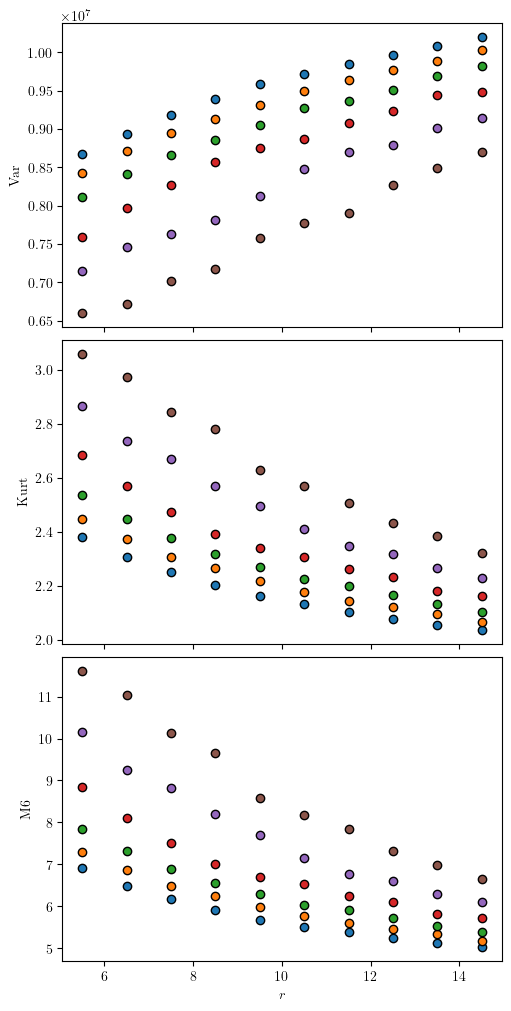

In [11]:
# what do the moments of Pvlos look like as fcns of R|M?

fig, ax = plt.subplots(3, 1, figsize=(5, 10), sharey='row', sharex=True, layout='constrained')

moments = np.zeros((3, len(Mvirs), len(r_cens)))

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        data = vphyslos_ls[i + k*len(r_cens)]
        
        m2 = np.var(data)
        #m3 = (np.mean(data**3) / np.std(data)**3)
        m4 = (np.mean(data**4)/ np.std(data)**4 )
        #m5 = (np.mean(data**5) / np.std(data)**5)
        m6 = (np.mean(data**6) / np.std(data)**6)

        moments[:, k, i] = np.array([m2, m4, m6])

moms = [r"Var", r"Kurt", r"M6"]

for j in range(3):
    for k in range(len(Mvirs)):
        ax[j].scatter(r_cens, moments[j, k, :], edgecolor='black')
        ax[j].set_ylabel(moms[j])

ax[2].set_xlabel(r"$r$")

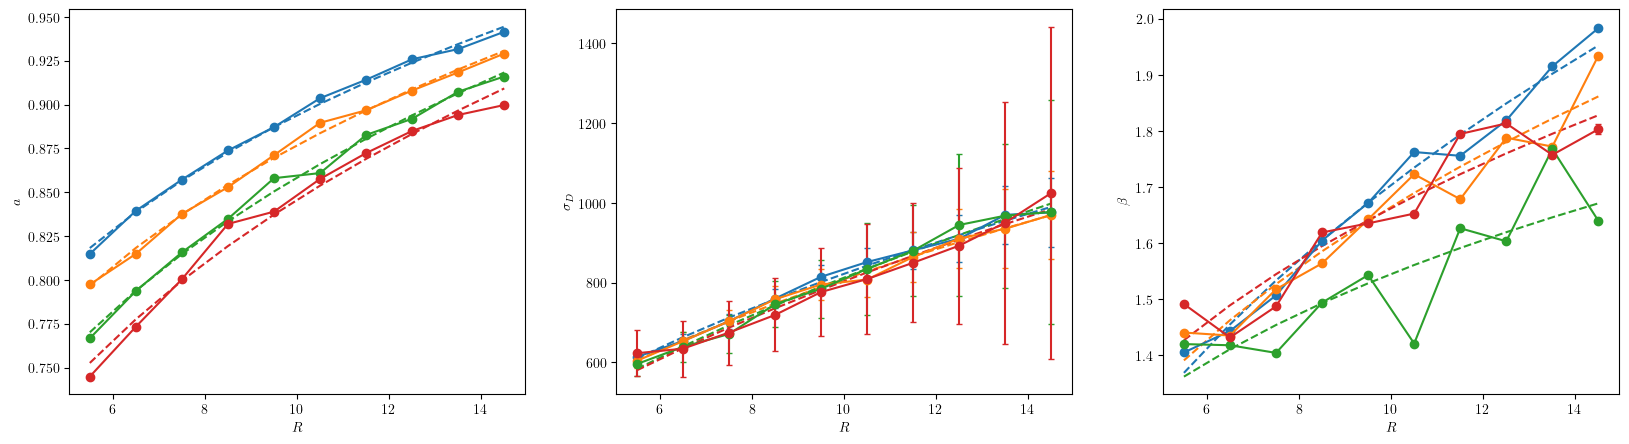

In [31]:
fig, ax = plt.subplots(1, len(p_init), figsize=(20, 5))
labels = [r"$a$", r"$\sigma_D$", r"$\beta$"]

mm_r_pars = np.zeros((len(Mvirs), len(p_init), 2))

for j in range(len(p_init)):
    for k in range(len(Mvirs)-2):
        p, _ = curve_fit(plaw, r_cens/10, mm_pars[k, :, j])
        mm_r_pars[k, j] = p
        ax[j].errorbar(r_cens, mm_pars[k, :, j], mm_errs[k, :, j]**2, fmt='o-', capsize=2)
        ax[j].plot(r_cens, plaw(r_cens/10, p[0], p[1]), c=f'C{k}', ls='--')
        #ax[j].plot(r_cens, mm_pars[k, :, j])
        ax[j].set_ylabel(labels[j])
        ax[j].set_xlabel(r"$R$")
            

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2572496/2973648731.py:2: SyntaxWarning: invalid escape sequence '\s'
  labels = [[r"$a_p$", r"$a_s$"], [r"$\sigma_{D, p}$", "$\sigma_{D, s}$"], [r"$\beta_p$", r"$\beta_s$"]]


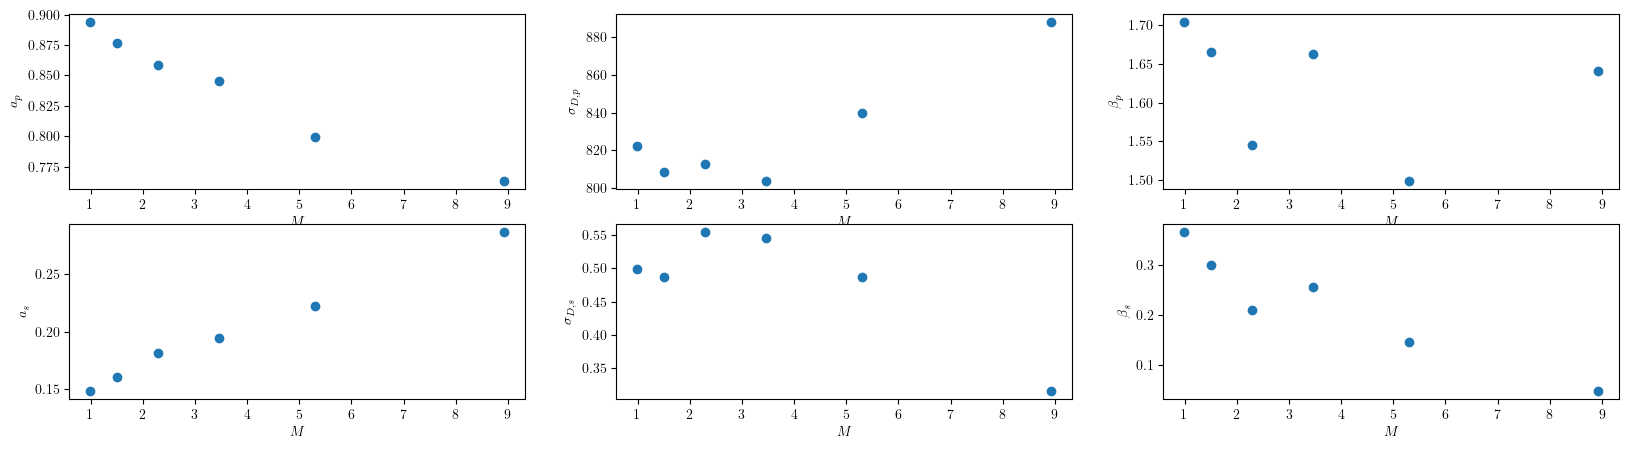

In [230]:
fig, ax = plt.subplots(2, len(p_init), figsize=(20, 5))
labels = [[r"$a_p$", r"$a_s$"], [r"$\sigma_{D, p}$", "$\sigma_{D, s}$"], [r"$\beta_p$", r"$\beta_s$"]]

mm_m_pars = np.zeros((len(p_init), 2))

for i in range(mm_r_pars.shape[-1]):
    for j in range(len(p_init)):
        ax[i, j].scatter(Mvirs/1e14, mm_r_pars[:, j, i])
        ax[i, j].set_xlabel(r"$M$")
        ax[i, j].set_ylabel(labels[j][i])

In [ ]:
i = 0
k = 0
p_init = [0.5, 500, 1500, 2]

soln = scipy.optimize.minimize(lambda p: -llh_ind(p, v_cens, LOS_hists[:, k, i]), p_init, 
                                    bounds = [(0, 1), (2500, 6000), (0, 2500), (0, 10)], 
                                    method='nelder-mead', 
                                    options={'disp':True}
                                    )

Optimization terminated successfully.
         Current function value: 0.005231
         Iterations: 247
         Function evaluations: 424


/tmp/ipykernel_2572496/1185885925.py:6: OptimizeWarning: Initial guess is not within the specified bounds
  soln = scipy.optimize.minimize(lambda p: -llh_ind(p, v_cens, LOS_hists[:, k, i]), p_init,


In [107]:
i = 0
k = 0
p_init = [0.5, 500, 2.0]


result = scipy.optimize.minimize(lambda p: -llh_ind_obs(p, v_cens, LOS_hists[:, k, i], r_cens[i], Mvirs[k]), p_init, 
                                    #bounds = [(0, 1), (0, np.inf), (0, np.inf)], 
                                    method='nelder-mead', 
                                    options={'disp':True}
                                    )

Optimization terminated successfully.
         Current function value: 0.055853
         Iterations: 214
         Function evaluations: 380


In [63]:
soln.x

array([8.06240893e-01, 4.05983690e+03, 6.01718951e+02, 1.39680711e+00])

In [108]:
result.x

array([1.30743685e-01, 3.28216480e+03, 6.37813504e-01])

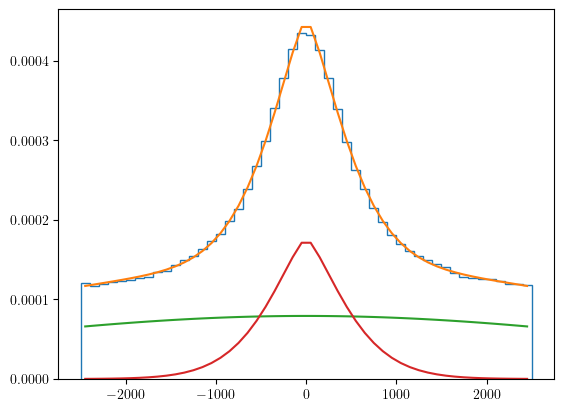

In [77]:
i = 0
k = 0

vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:] + vedges[:-1])

hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step')
plt.plot(vcens, P_mm(vcens, soln.x))
plt.plot(vcens, soln.x[0]*P_broad(vcens, soln.x[1]))
plt.plot(vcens, (1-soln.x[0])*P_D(vcens, soln.x[2], soln.x[3]))
#plt.plot(vcens, P_H(vcens, r_cens[i], Mvirs[k]))
#plt.plot(vcens, (hist-soln.x[0]*P_H(vcens, r_cens[i], Mvirs[k]))/(1-soln.x[0]))

Text(0.5, 0, '$v_{\\rm LOS}$')

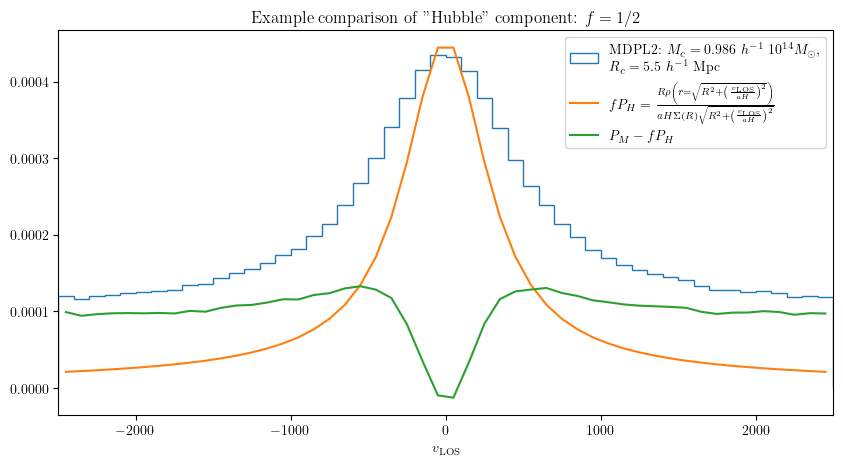

In [50]:
i = 0
k = 0

vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:] + vedges[:-1])

plt.figure(figsize=(10, 5))

denom = 2
f = 1/denom #1/4

hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step', label=f"MDPL2: $M_c={mvirs[k]:.3} \ h^{{-1}}\ 10^{{14}} M_\odot$, \n $R_c={r_cens[i]} \ h^{{-1}}$ Mpc")
#plt.plot(vcens, P_obs(vcens, r_cens[i], Mvirs[k], result.x))
plt.plot(vcens, f*P_H(vcens, r_cens[i], Mvirs[k]), label=r"$fP_H = \frac{R\rho\left(r=\sqrt{R^2+\left ( \frac{v_{\rm LOS}}{aH} \right)^2}\right)}{aH\Sigma(R)\sqrt{R^2+\left ( \frac{v_{\rm LOS}}{aH} \right)^2}}$")
#plt.plot(vcens, result.x[0]*P_H(vcens, r_cens[i], Mvirs[k]))
plt.plot(vcens, ((hist - f*P_H(vcens, r_cens[i], Mvirs[k])) ), label=r'$P_M - fP_H$')

plt.legend(loc='upper right', fontsize=10)
plt.margins(x=0)
plt.title(f'Example comparison of "Hubble" component: $f=1/{denom}$')
plt.xlabel(r"$v_{\rm LOS}$")

In [43]:
import warnings
warnings.filterwarnings('ignore')

<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_732602/1463672023.py:12: SyntaxWarning: invalid escape sequence '\ '
  hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step', label=f"MDPL2: $M_c={mvirs[k]:.3} \ h^{{-1}}\ 10^{{14}} M_\odot$, \n $R_c={r_cens[i]} \ h^{{-1}}$ Mpc")
/tmp/ipykernel_732602/1463672023.py:12: SyntaxWarning: invalid escape sequence '\ '
  hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step', label=f"MDPL2: $M_c={mvirs[k]:.3} \ h^{{-1}}\ 10^{{14}} M_\odot$, \n $R_c={r_c

Text(0.5, 0, '$v_{\\rm LOS}$')

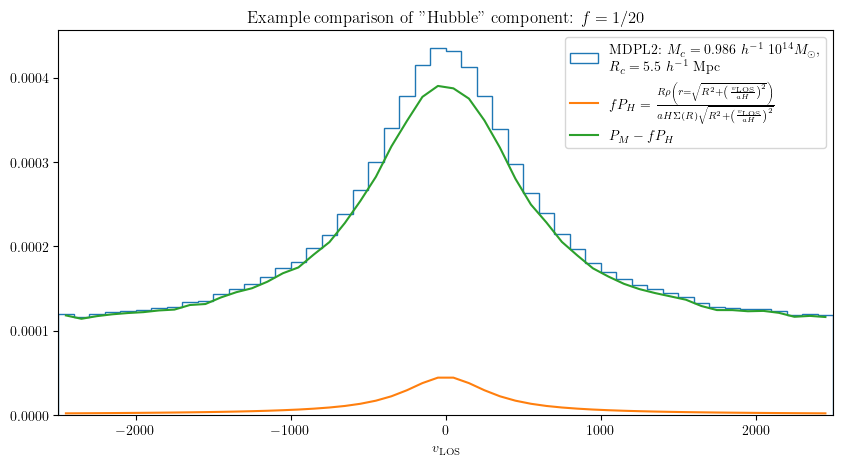

In [30]:
i = 0
k = 0

vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:] + vedges[:-1])

plt.figure(figsize=(10, 5))

denom = 20
f = 1/denom #1/4

hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step', label=f"MDPL2: $M_c={mvirs[k]:.3} \ h^{{-1}}\ 10^{{14}} M_\odot$, \n $R_c={r_cens[i]} \ h^{{-1}}$ Mpc")
#plt.plot(vcens, P_obs(vcens, r_cens[i], Mvirs[k], result.x))
plt.plot(vcens, f*P_H(vcens, r_cens[i], Mvirs[k]), label=r"$fP_H = \frac{R\rho\left(r=\sqrt{R^2+\left ( \frac{v_{\rm LOS}}{aH} \right)^2}\right)}{aH\Sigma(R)\sqrt{R^2+\left ( \frac{v_{\rm LOS}}{aH} \right)^2}}$")
#plt.plot(vcens, result.x[0]*P_H(vcens, r_cens[i], Mvirs[k]))
plt.plot(vcens, ((hist - f*P_H(vcens, r_cens[i], Mvirs[k])) ), label=r'$P_M - fP_H$')

plt.legend(loc='upper right', fontsize=10)
plt.margins(x=0)
plt.title(f'Example comparison of "Hubble" component: $f=1/{denom}$')
plt.xlabel(r"$v_{\rm LOS}$")

In [17]:
from scipy.optimize import curve_fit

In [25]:
p

array([1., 1.])

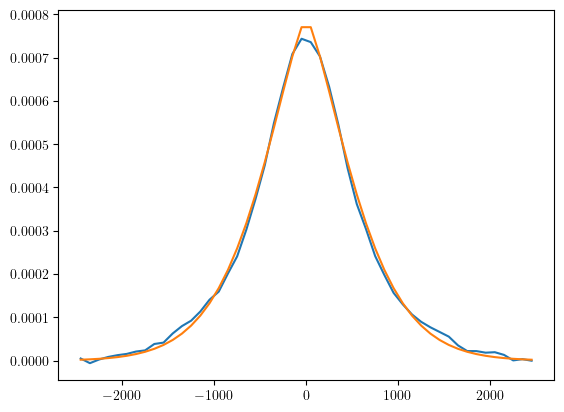

In [36]:
PD = ((hist - f*P_H(vcens, r_cens[i], Mvirs[k])) )
PD = PD - PD[-1]
PD = PD / (np.sum(PD)*np.diff(vcens)[0])

p, c = curve_fit(lambda x, b, s: gennorm.pdf(x, b, loc=0, scale=s), vcens, PD, p0=[2, 700])

plt.plot(vcens, PD, label=r'$P_M - fP_H$')
plt.plot(vcens, gennorm.pdf(vcens, 1.4, scale=p[1]))


In [33]:
p

array([  1.3590889 , 694.64600607])

In [24]:
np.sum(PD)*np.diff(vcens)[0]

np.float64(1.0)

In [132]:
result.x[0]

np.float64(0.13074368474689246)

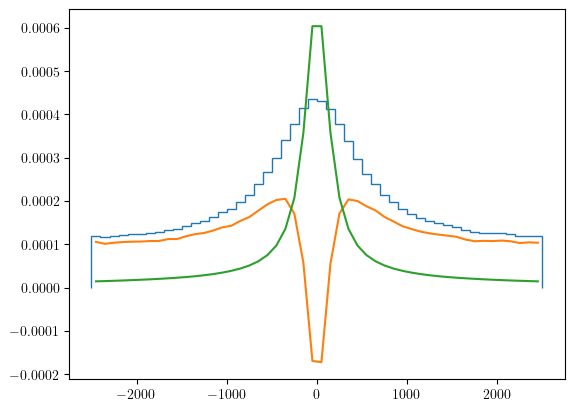

In [184]:
hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step')

a = 0.4
plt.plot(vcens, (hist - a*P_H(vcens, r_cens[i], Mvirs[k])))
plt.plot(vcens, a*P_H(vcens, r_cens[i], Mvirs[k]))
#plt.plot(vcens, (1-result.x[0])*gennorm.pdf(vcens, 2.8, scale=700))


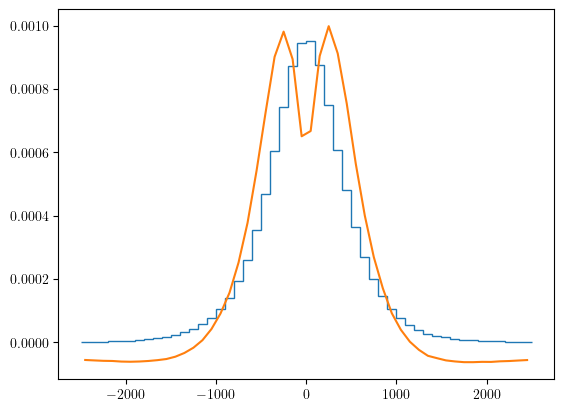

In [174]:
hist2, _, _ = plt.hist(vpeclos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step')

#a_s = 0.1*np.arange(10)
#for a in a_s:
a = 0.6
plt.plot(vcens, (hist2 - a*P_H(vcens, r_cens[i], Mvirs[k]))/(1-a))

#plt.yscale('log')
#plt.plot(vcens, a*P_H(vcens, r_cens[i], Mvirs[k])) 

#plt.plot(vcens, (1-result.x[0])*gennorm.pdf(vcens, 2.8, scale=700))


In [ ]:
np.max(P_H(vcens, r_cens[i], Mvirs[k]))

In [57]:
import ipywidgets as widgets
from IPython.display import display

# Create sliders for p_init parameters
p0_slider = widgets.FloatSlider(
    value=p_init[0], 
    min=0.0, 
    max=1.0, 
    step=0.01,
    description='a:',
    continuous_update=False
)

p1_slider = widgets.FloatSlider(
    value=p_init[1],
    min=0,
    max=10_000,
    step=100,
    description=r'$\sigma_B$:',
    continuous_update=False
)

p2_slider = widgets.FloatSlider(
    value=p_init[2],
    min=0,
    max=10_000,
    step=100,
    description=r'$\sigma_D$:',
    continuous_update=False
)


p3_slider = widgets.FloatSlider(
    value=p_init[3],
    min=0,
    max=5,
    step=0.1,
    description=r'$\beta$:',
    continuous_update=False
)

# Define the plotting function
def update_plot(p0, p1, p2, p3):
    plt.figure(figsize=(8, 5))
    
    i = 5
    k = 0
    
    vedges = np.linspace(-2500, 2500, 50+1)
    vcens = 0.5*(vedges[1:] + vedges[:-1])
    
    p_current = [p0, p1, p2, p3]
    
    hist, _, _ = plt.hist(vphyslos_ls[i + k*len(r_cens)], bins=vedges, 
                          range=[-2500, 2500], density=True, histtype='step',
                          label='Data')
    plt.plot(vcens, 2*P_mm(vcens, p_current), 
             label='P_obs', linewidth=2)
    plt.plot(vcens, p0*P_broad(vcens, p1), 
             label=f'P_broad ({p0:.2f})', linewidth=2)
    plt.plot(vcens, (1-p0)*P_D(vcens, p2, p3), 
             label=f'P_D ({1-p0:.2f})', linewidth=2)
    
    plt.xlabel('Velocity')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(np.sum(hist)*np.diff(vcens)[0], np.sum(2*P_mm(vcens, p_current))*np.diff(vcens)[0])

# Create interactive plot
widgets.interactive(update_plot, p0=p0_slider, p1=p1_slider, p2=p2_slider, p3=p3_slider)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='a:', max=1.0, step=0.01), F…

In [ ]:
H = cosmo.Hz(redshift)

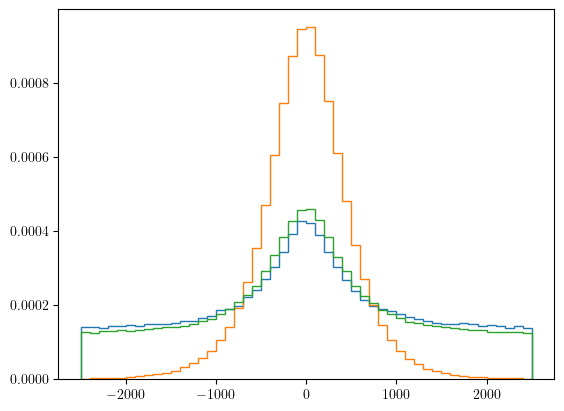

In [84]:
hist, _, _ = plt.hist(a*H*rlos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step')
hist, _, _ = plt.hist(vpeclos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step')
hist, _, _ = plt.hist(vpeclos_ls[i + k*len(r_cens)]+ a*H*rlos_ls[i + k*len(r_cens)], bins=vedges, range=[-2500, 2500], density=True, histtype='step')


Inspecting relation to $\xi_{\rm mm}$ 

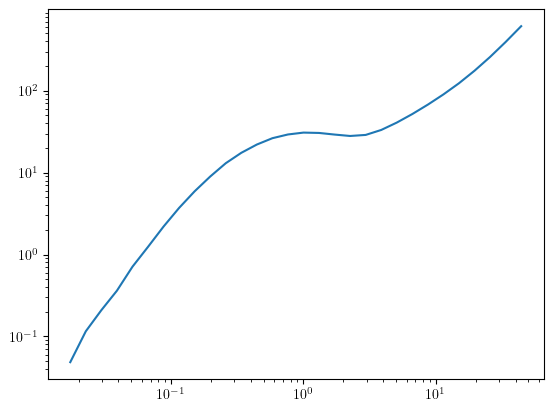

In [2]:
path_mm = '/spiff/edgarmsc/halo_tpcf/MDPL2/ximm.hdf5'

with h5.File(path_mm, 'r') as hdf:
    #print(hdf.keys())

    r = hdf['rbins'][()]
    ximm = hdf['xi'][()]

    plt.plot(r, r**2*ximm)
    plt.xscale('log')
    plt.yscale('log')


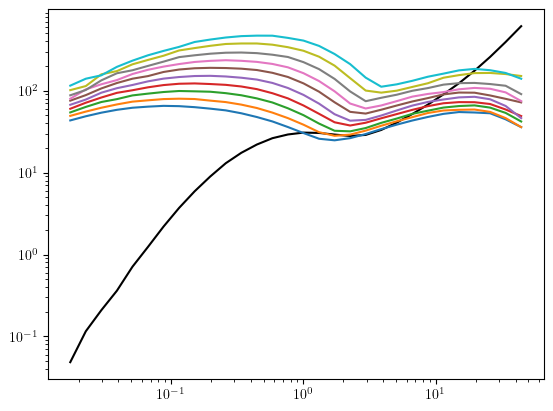

In [3]:

path_hm = '/spiff/edgarmsc/halo_tpcf/MDPL2/xihm.hdf5'

with h5.File(path_hm, 'r') as hdf:
    #print(hdf['xi'].keys())
    mstr = hdf['xi'].keys()
    r = hdf['rbins'][()]

    plt.plot(r, r**2*ximm, c='k')

    for k, M in enumerate(mstr):
        xihm = hdf['xi'][M][()]

        plt.plot(r, r**2*xihm)
        plt.xscale('log')
        plt.yscale('log')

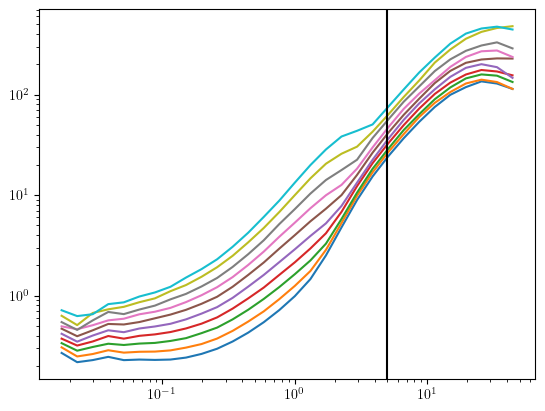

In [23]:
# what does the halo bias look like?

with h5.File(path_hm, 'r') as hdf:
    #print(hdf['xi'].keys())
    mstr = hdf['xi'].keys()
    r = hdf['rbins'][()]

    halo_bias = np.zeros((len(mstr), len(r)))

    for k, M in enumerate(mstr):
        xihm = hdf['xi'][M][()]

        plt.plot(r, r**2*(xihm/ximm))
        plt.xscale('log')
        plt.yscale('log')

        halo_bias[k] = xihm/ximm

plt.axvline(5, c='k')

In [10]:
with h5.File(path_hm, 'r') as hdf:
    mass_bins = 10**(hdf['mass_bins'][()])

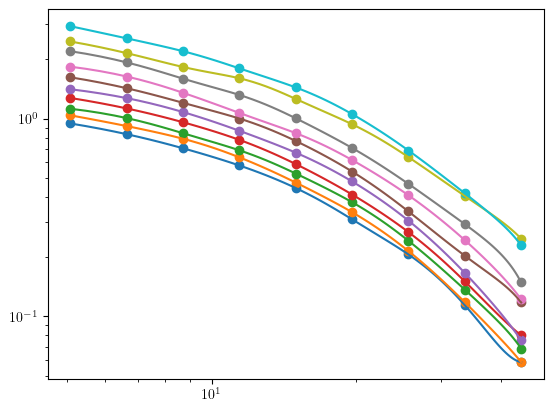

In [38]:
from scipy.interpolate import RegularGridInterpolator

rl = r[r>5]
bias = halo_bias[:, r > 5]


# build interpolator
b_interp = RegularGridInterpolator((mass_bins, rl), bias, method='cubic', bounds_error=False, fill_value=None)

r_sm = np.linspace(rl.min(), rl.max(), 100)
#M_sm = np.logspace(np.log10(mass_bins.min()), np.log10(mass_bins.max()), 100)

for k in range(len(mass_bins)):
    b = np.array([b_interp((mass_bins[k], ri)) for ri in r_sm])

    plt.scatter(rl, halo_bias[k][r>5])
    plt.plot(r_sm, b)
#plt.ylim((0, 3))
plt.xscale('log')
plt.yscale('log')

In [37]:
np.log10(mass_bins)

array([13.575, 13.725, 13.875, 14.025, 14.175, 14.325, 14.475, 14.625,
       14.775, 14.925])

In [36]:
np.log10(Mvirs)

array([13.994061, 14.175599, 14.361029, 14.539741, 14.72489 , 14.950905],
      dtype=float32)

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


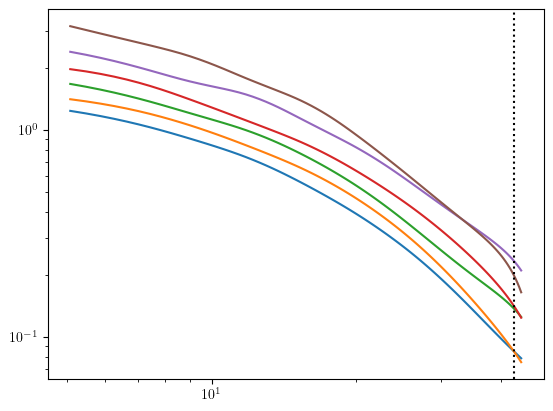

In [42]:
# looks ok for my mass bins? yep.

Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

for k in range(len(Mvirs)):
    b = np.array([b_interp((Mvirs[k], ri)) for ri in r_sm])

    #plt.scatter(rl, halo_bias[k][r>5])
    plt.plot(r_sm, b)

#plt.ylim((0, 3))
plt.axvline(np.sqrt(14.5**2 + 40**2), c='k', ls=':')
plt.xscale('log')
plt.yscale('log')

In [44]:
# interpolate xi_mm, define xi_hm function
from scipy.interpolate import CubicSpline

ximm_interp = CubicSpline(rl, ximm[r > 5])

def xihm_interp(r, M):

    return b_interp((M, r))*ximm_interp(r)

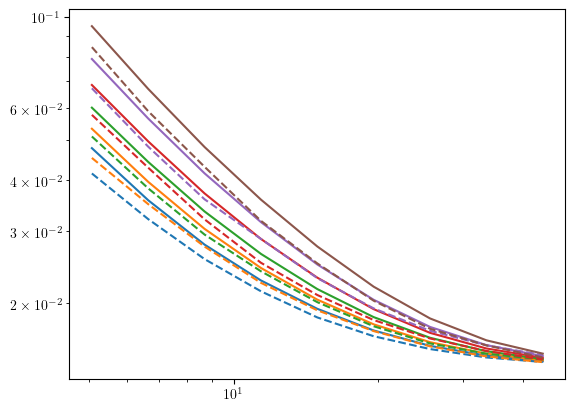

In [47]:
# How does this compare to predictions from Edgar's model?

n_gal = 0.014 # h^3 Mpc^-3 , avgh dens of gals in sim

for k, M in enumerate(Mvirs):

    dh = 0.014 * (1+cf_inf(rl, M, params=cf_pars))
    hm = 0.014 * (1+xihm_interp(rl, M))

    plt.plot(rl, dh, c=f'C{k}')
    plt.plot(rl, hm, c=f'C{k}', ls='--')

plt.yscale('log')
plt.xscale('log')